In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('churn_raw_data.csv')

print(df.head())

   Unnamed: 0  CaseOrder Customer_id                           Interaction  \
0           1          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1           2          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2           3          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3           4          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4           5          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

          City State                 County    Zip       Lat        Lng  ...  \
0  Point Baker    AK  Prince of Wales-Hyder  99927  56.25100 -133.37571  ...   
1  West Branch    MI                 Ogemaw  48661  44.32893  -84.24080  ...   
2      Yamhill    OR                Yamhill  97148  45.35589 -123.24657  ...   
3      Del Mar    CA              San Diego  92014  32.96687 -117.24798  ...   
4    Needville    TX              Fort Bend  77461  29.38012  -95.80673  ...   

   MonthlyCharge Bandwidth_GB_Year item1 item2  it

In [26]:
#cleans any duplicates
df = df.drop_duplicates()

# Prints # of rows that have duplicates
print(df.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [27]:
df = pd.read_csv('churn_raw_data.csv')

# Checks for missing values
missing_values = df.isnull().sum()

# Filter out columns that have no missing values
missing_values = missing_values[missing_values > 0]

# Print the columns that have missing values
print("Columns with missing values and their counts:\n", missing_values)

# Calculate and print mean, median for numeric columns, and mode for non-numeric columns
for column in missing_values.index:
    if df[column].dtype in ['float64', 'int64']:
        mean_value = df[column].mean()
        median_value = df[column].median()
        print(f"\nColumn: {column}")
        print(f"  Mean: {mean_value}")
        print(f"  Median: {median_value}")
    else:
        # Calculate the mode for non-numeric columns
        mode_value = df[column].mode()[0]
        print(f"\nColumn: {column}")
        print(f"  Mode: {mode_value}")

Columns with missing values and their counts:
 Children             2495
Age                  2475
Income               2490
Techie               2477
InternetService      2129
Phone                1026
TechSupport           991
Tenure                931
Bandwidth_GB_Year    1021
dtype: int64

Column: Children
  Mean: 2.095936042638241
  Median: 1.0

Column: Age
  Mean: 53.27574750830565
  Median: 53.0

Column: Income
  Mean: 39936.76222636485
  Median: 33186.785

Column: Techie
  Mode: No

Column: InternetService
  Mode: Fiber Optic

Column: Phone
  Mode: Yes

Column: TechSupport
  Mode: No

Column: Tenure
  Mean: 34.49885764604521
  Median: 36.19603

Column: Bandwidth_GB_Year
  Mean: 3398.842752015135
  Median: 3382.424


In [29]:
#(Kumar, 2023)
# Replace N/A values in the 'Children' column with the median
df['Children'] = df['Children'].fillna(df['Children'].median())
print("The new amount of null values for Children:", df['Children'].isnull().sum())

# Impute missing values in 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())
print("The new amount of null values for Age:", df['Age'].isnull().sum())

# Impute missing values with mode for 'Techie', 'Phone', and 'TechSupport' columns
for column in ['Techie', 'Phone', 'TechSupport']:
    df[column] = df[column].fillna(df[column].mode()[0])

# For 'InternetService', replace missing values with 'None' to indicate valid option
df['InternetService'] = df['InternetService'].fillna('Neither')

# Verify that there are no more missing values in these columns
print("The new amount of null values for:\n", df[['Techie', 'Phone', 'TechSupport', 'InternetService']].isnull().sum())

The new amount of null values for Children: 0
The new amount of null values for Age: 0
The new amount of null values for:
 Techie             0
Phone              0
TechSupport        0
InternetService    0
dtype: int64


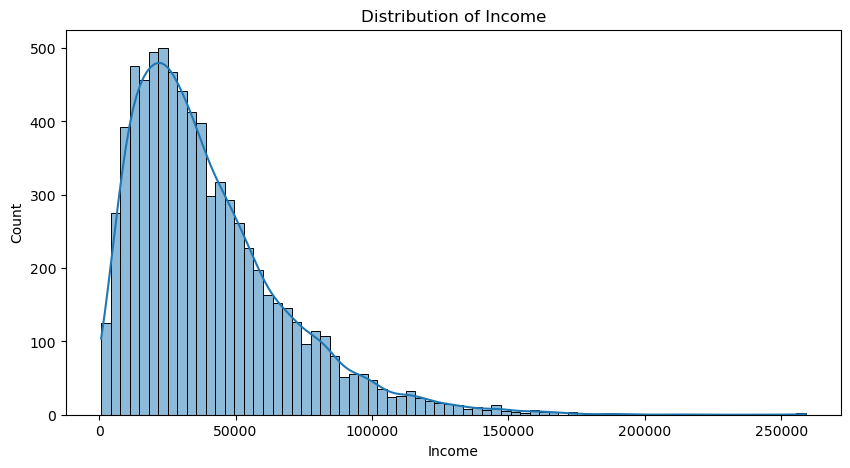

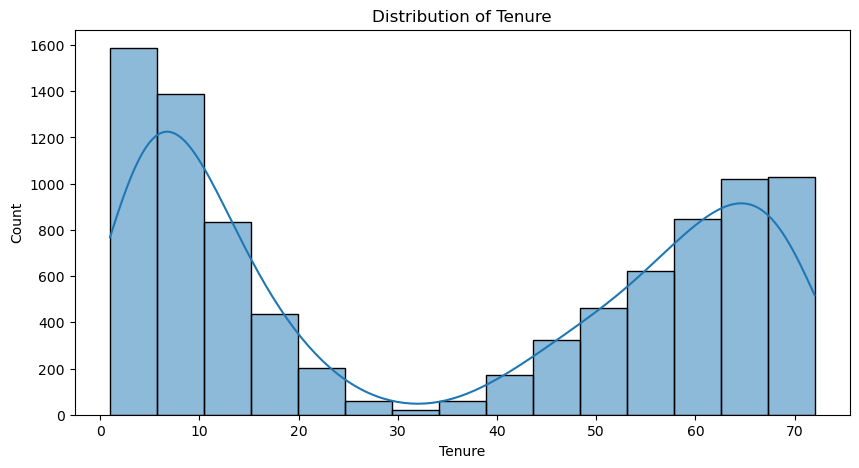

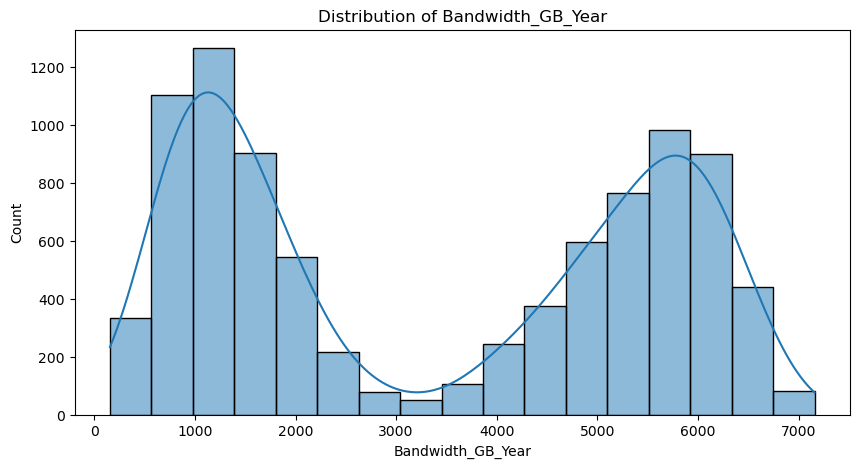

In [30]:
df = pd.read_csv('churn_raw_data.csv')

# Plot histogram for "Income" column
plt.figure(figsize=(10, 5))
sns.histplot(df['Income'].dropna(), kde=True)
plt.title('Distribution of Income')
plt.show()

# Plot histogram for "Tenure" column
plt.figure(figsize=(10, 5))
sns.histplot(df['Tenure'].dropna(), kde=True)
plt.title('Distribution of Tenure')
plt.show()

# Plot histogram for "Bandwidth_GB_Year" column
plt.figure(figsize=(10, 5))
sns.histplot(df['Bandwidth_GB_Year'].dropna(), kde=True)
plt.title('Distribution of Bandwidth_GB_Year')
plt.show()

In [31]:
#(Kumar, 2023)
# Impute 'Income' column with median
df['Income'] = df['Income'].fillna(df['Income'].median())

# Impute 'Tenure' column with mean
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())

# Impute 'Bandwidth_GB_Year' column with median
df['Bandwidth_GB_Year'] = df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].median())

# Verify that there are no more missing values in these columns
print("The new amount of null values in Income:", df['Income'].isnull().sum())
print("The new amount of null values in Tenure:", df['Tenure'].isnull().sum())
print("The new amount of null values in Bandwidth_GB_Year:", df['Bandwidth_GB_Year'].isnull().sum())

The new amount of null values in Income: 0
The new amount of null values in Tenure: 0
The new amount of null values in Bandwidth_GB_Year: 0


In [38]:
#(Bobbitt, 2021)

df = pd.read_csv('churn_raw_data.csv')

# Select only the numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Calculate Z-scores for all numeric columns
z_scores = np.abs(stats.zscore(numeric_cols))

# Create a boolean DataFrame where True indicates an outlier (Z-score > 3)
outliers = (z_scores > 3)

# Filter the rows where any column has an outlier
outliers_df = numeric_cols[outliers.any(axis=1)]

# Count the number of outliers in each numeric column
outlier_counts = outliers.sum(axis=0)

# Get the min and max values of outliers for each column
outlier_ranges = {}
for column in numeric_cols.columns:
    if outlier_counts[column] > 0:
        column_outliers = numeric_cols[column][outliers[column]]
        outlier_ranges[column] = (column_outliers.min(), column_outliers.max())

# Output the outlier counts and ranges
print("Outlier counts per column:\n", outlier_counts)
print("\nOutlier ranges per column:\n", outlier_ranges)

Outlier counts per column:
 Unnamed: 0                0
CaseOrder                 0
Zip                       0
Lat                     151
Lng                     102
Population              219
Children                  0
Age                       0
Income                    0
Outage_sec_perweek      491
Email                    12
Contacts                165
Yearly_equip_failure     94
Tenure                    0
MonthlyCharge             3
Bandwidth_GB_Year         0
item1                    19
item2                    13
item3                    13
item4                     9
item5                    12
item6                    13
item7                    11
item8                    15
dtype: int64

Outlier ranges per column:
 {'Lat': (17.96612, 70.64066), 'Lng': (-171.68815, -143.078), 'Population': (53098, 111850), 'Outage_sec_perweek': (32.58126, 47.04928), 'Email': (1, 23), 'Contacts': (4, 7), 'Yearly_equip_failure': (3, 6), 'MonthlyCharge': (306.268, 315.8786), 'item1': (7, 7

In [33]:
df = pd.read_csv('churn_raw_data.csv')

# Display unique values in specified categorical columns
for column in ['Churn', 'Techie', 'Port_modem', 'Tablet', 'Phone', 'Multiple', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']:
    print(f"Unique values in {column}: {df[column].unique()}")

Unique values in Churn: ['No' 'Yes']
Unique values in Techie: ['No' 'Yes' nan]
Unique values in Port_modem: ['Yes' 'No']
Unique values in Tablet: ['Yes' 'No']
Unique values in Phone: ['Yes' 'No' nan]
Unique values in Multiple: ['No' 'Yes']
Unique values in OnlineSecurity: ['Yes' 'No']
Unique values in OnlineBackup: ['Yes' 'No']
Unique values in DeviceProtection: ['No' 'Yes']
Unique values in TechSupport: ['No' 'Yes' nan]
Unique values in StreamingTV: ['No' 'Yes']
Unique values in StreamingMovies: ['Yes' 'No']
Unique values in PaperlessBilling: ['Yes' 'No']


In [24]:
# Save the DataFrame to the specified path
#df.to_csv(r'D:\WGU\D206\cleaned_churn_data.csv', index=False)
#df.to_csv('cleaned_churn_data.csv')

In [34]:
from sklearn.decomposition import PCA
import seaborn as scn

# Load the data
df = pd.read_csv('cleaned_churn_data.csv')

#df of all quantitative continuous variables
p_df = df[['Lat', 'Lng', 'Income', 'Outage_sec_perweek', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']]

#Normalize data using Mean and Standard deviation
p_normalized = (p_df - p_df.mean()) / p_df.std()

#Number of components
pca = PCA(p_df.shape[1])
print("The number of components are: ", pca)

pca.fit(p_normalized)

The number of components are:  PCA(n_components=7)


PCA(n_components=7)

In [35]:
p_pca = pd.DataFrame(pca.transform(p_normalized),
columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])

In [36]:
#Load PCA
loadings = pd.DataFrame(pca.components_.T,
columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'],
index = p_df.columns)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Lat,-0.022798,0.217839,0.668587,-0.016855,-0.710318,0.013490,0.000622
Lng,0.008489,-0.141940,-0.688363,0.130087,-0.693037,0.093349,0.000608
Income,0.005725,0.021677,0.098806,0.990007,0.074770,-0.063484,0.000929
Outage_sec_perweek,0.021764,0.691045,-0.136267,0.036159,0.095445,0.702137,-0.000032
Tenure,0.705158,-0.050835,0.031454,-0.002521,-0.008499,0.035532,-0.705576
MonthlyCharge,0.045566,0.672141,-0.222632,-0.036413,-0.017392,-0.701905,-0.047819
Bandwidth_GB_Year,0.706808,-0.005338,0.016200,-0.006375,-0.008531,-0.011991,0.707018


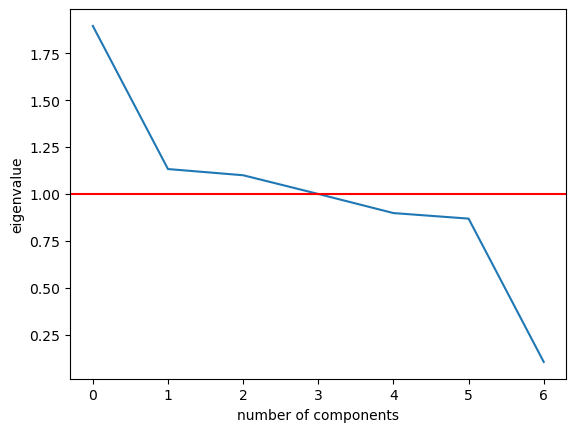

In [37]:
#Create covarience matrix
cov_matrix = np.dot(p_normalized.T, p_normalized) / p_df.shape[0]

#Calculate Eigenvalues
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]

#Plot Eigenvalues
plt.plot(eigenvalues)
plt.xlabel('number of components')
plt.ylabel('eigenvalue')
plt.axhline(y=1, color="red")
plt.show()